## Step 1 — Imports

In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms

from NST_Code.utils.models import StyleTransferModel

## Step 2 — Configuration

In [11]:
ROOT = Path.cwd()

VGG_WEIGHTS = ROOT / "NST_Code" / "vgg_normalised.pth"
# Point this at whichever checkpoint train.py saved that you want to evaluate,
# e.g. ROOT / "experiment" / "run1" / "decoder_iter_20000.pth"
DECODER_WEIGHTS = ROOT / "NST_Code" / "experiment" / "run1" / "decoder_iter_1000.pth"

CONTENT_IMAGE = ROOT / "NST_Code" / "examples" / "brad_pitt.jpg"
STYLE_IMAGES = {
    "Style A": ROOT / "NST_Code" / "examples" / "sketch.png",
    "Style B": ROOT / "NST_Code" / "examples" / "picasso_seated_nude_hr.jpg",
}
OUTPUT_DIR = ROOT / "NST_Code" / "examples" / "generated"

for label, path in [("VGG weights", VGG_WEIGHTS), ("Decoder weights", DECODER_WEIGHTS), ("Content image", CONTENT_IMAGE)]:
    if not path.exists():
        raise FileNotFoundError(f"{label} not found at {path}. Update the path above.")
missing_styles = [str(p) for p in STYLE_IMAGES.values() if not p.exists()]
if missing_styles:
    raise FileNotFoundError("These style images were not found:\n  " + "\n  ".join(missing_styles))

image_size = 512
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
])

style_model = StyleTransferModel(str(VGG_WEIGHTS), decoder_path=str(DECODER_WEIGHTS))
device = style_model.device
print("Using device:", device)
print("VGG weights:", VGG_WEIGHTS)

Using device: cuda
VGG weights: D:\Mojar Project\Neural style transfer\NST_Code\vgg_normalised.pth


## Step 3 — Generate stylized images from your trained decoder

In [12]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def load_as_tensor(path):
    image = Image.open(path).convert("RGB")
    return transform(image).unsqueeze(0).to(device)

content_tensor = load_as_tensor(CONTENT_IMAGE)

image_paths = {"Original": CONTENT_IMAGE}

for style_name, style_path in STYLE_IMAGES.items():
    style_tensor = load_as_tensor(style_path)
    stylized = style_model.stylize(content_tensor, style_tensor, alpha=1.0)
    out_path = OUTPUT_DIR / f"stylized_{style_name.replace(' ', '_').lower()}.png"
    from torchvision.utils import save_image
    save_image(stylized, str(out_path))
    image_paths[f"Stylized ({style_name})"] = out_path
    print(f"Generated {out_path}")

Generated D:\Mojar Project\Neural style transfer\NST_Code\examples\generated\stylized_style_a.png
Generated D:\Mojar Project\Neural style transfer\NST_Code\examples\generated\stylized_style_b.png


## Step 4 — Helper functions

In [13]:
def load_image(path):
    image = Image.open(path).convert("RGB")
    tensor = transform(image).unsqueeze(0).to(device)
    return image, tensor


def extract_features(tensor):
    # Reuses style_model's own encoder rather than loading vgg_normalised.pth
    # a second time.
    with torch.no_grad():
        h1, h2, h3, h4 = style_model.encoder(tensor)
        return {
            "relu1_1": h1,
            "relu2_1": h2,
            "relu3_1": h3,
            "relu4_1": h4,
        }


def activation_map(feature_tensor):
    """Collapse a (1, C, H, W) feature map to a normalised (H, W) heatmap."""
    activation = feature_tensor[0].mean(dim=0).detach().cpu()
    activation = activation - activation.min()
    activation = activation / (activation.max() + 1e-8)
    return activation


def content_similarity(feature_a, feature_b):
    """
    Cosine similarity between two feature maps, flattened to vectors.
    1.0 = identical activations (perfect content preservation at this layer).
    0.0 = completely unrelated activations.
    Feature maps are resized to match if the two images differ in size.
    """
    if feature_a.shape[-2:] != feature_b.shape[-2:]:
        feature_b = F.interpolate(feature_b, size=feature_a.shape[-2:], mode="bilinear", align_corners=False)
    a = feature_a.flatten()
    b = feature_b.flatten()
    return F.cosine_similarity(a.unsqueeze(0), b.unsqueeze(0)).item()

## Step 5 — Load every image and extract its features

In [14]:
image_tensors = {}
feature_bank = {}

for name, path in image_paths.items():
    _, tensor = load_image(path)
    image_tensors[name] = tensor
    feature_bank[name] = extract_features(tensor)

for name, features in feature_bank.items():
    shapes = {layer: tuple(feature.shape) for layer, feature in features.items()}
    print(name)
    print(shapes)
    print()

Original
{'relu1_1': (1, 64, 512, 512), 'relu2_1': (1, 128, 256, 256), 'relu3_1': (1, 256, 128, 128), 'relu4_1': (1, 512, 64, 64)}

Stylized (Style A)
{'relu1_1': (1, 64, 512, 512), 'relu2_1': (1, 128, 256, 256), 'relu3_1': (1, 256, 128, 128), 'relu4_1': (1, 512, 64, 64)}

Stylized (Style B)
{'relu1_1': (1, 64, 512, 512), 'relu2_1': (1, 128, 256, 256), 'relu3_1': (1, 256, 128, 128), 'relu4_1': (1, 512, 64, 64)}



## Step 6 — Quantitative content-preservation score

Content similarity vs 'Original' (1.0 = identical structure):

Stylized (Style A)
  relu1_1   : 0.4394
  relu2_1   : 0.4854
  relu3_1   : 0.4291
  relu4_1   : 0.5255

Stylized (Style B)
  relu1_1   : 0.2983
  relu2_1   : 0.3629
  relu3_1   : 0.3963
  relu4_1   : 0.5416



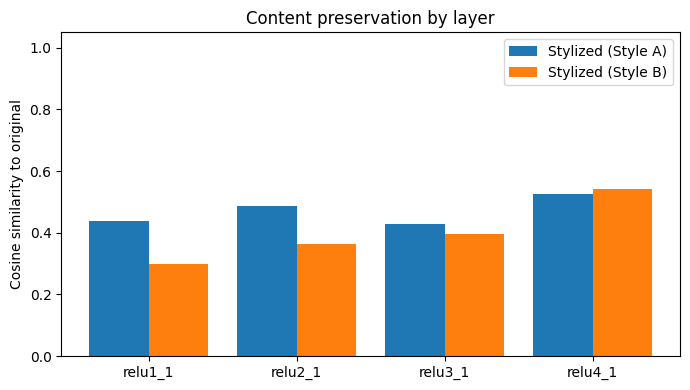

In [15]:
reference_name = list(image_paths.keys())[0]
comparison_names = list(image_paths.keys())[1:]
layers_to_show = ["relu1_1", "relu2_1", "relu3_1", "relu4_1"]

similarity_scores = {}
for name in comparison_names:
    similarity_scores[name] = {
        layer: content_similarity(feature_bank[reference_name][layer], feature_bank[name][layer])
        for layer in layers_to_show
    }

print(f"Content similarity vs '{reference_name}' (1.0 = identical structure):\n")
for name, scores in similarity_scores.items():
    print(name)
    for layer, score in scores.items():
        print(f"  {layer:10s}: {score:.4f}")
    print()

# Bar chart summary
fig, ax = plt.subplots(figsize=(7, 4))
bar_width = 0.8 / len(comparison_names)
x = range(len(layers_to_show))

for i, name in enumerate(comparison_names):
    offsets = [xi + i * bar_width for xi in x]
    ax.bar(offsets, [similarity_scores[name][layer] for layer in layers_to_show], width=bar_width, label=name)

ax.set_xticks([xi + bar_width * (len(comparison_names) - 1) / 2 for xi in x])
ax.set_xticklabels(layers_to_show)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Cosine similarity to original")
ax.set_title("Content preservation by layer")
ax.legend()
plt.tight_layout()
plt.savefig("content_similarity_scores.png", dpi=150)
plt.show()

## Step 7 — Visual comparison grid

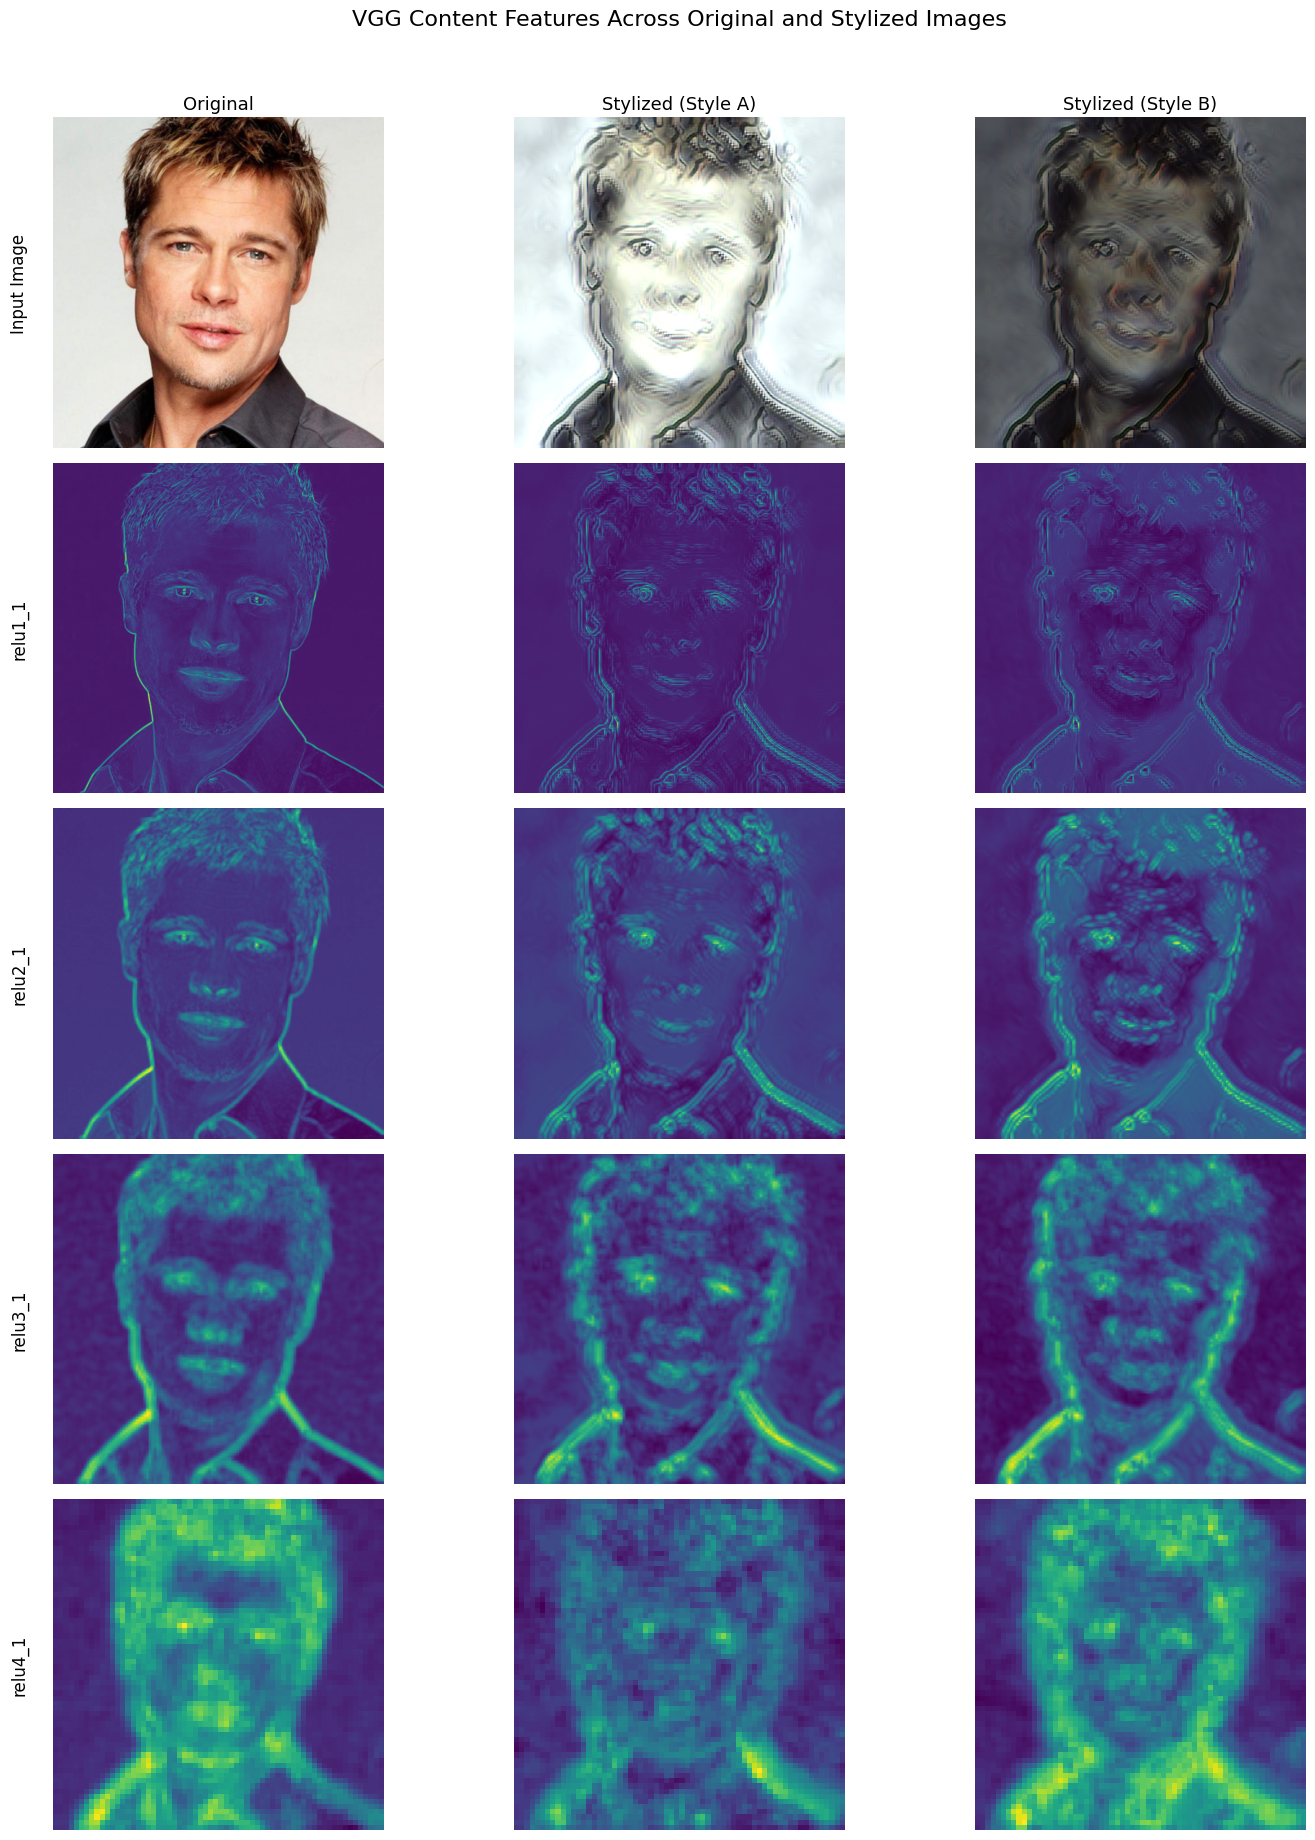

In [16]:
row_labels = ["Input Image"] + layers_to_show
num_rows = len(row_labels)
num_cols = len(image_paths)

fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 3.6 * num_rows), squeeze=False)

for col, (name, path) in enumerate(image_paths.items()):
    image = Image.open(path).convert("RGB")
    axes[0, col].imshow(image)
    axes[0, col].set_title(name, fontsize=13)
    axes[0, col].axis("off")

for row, layer in enumerate(layers_to_show, start=1):
    for col, name in enumerate(image_paths.keys()):
        axes[row, col].imshow(activation_map(feature_bank[name][layer]))
        axes[row, col].axis("off")

for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=12, rotation=90, labelpad=18)
    axes[row, 0].axis("on")
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])
    for spine in axes[row, 0].spines.values():
        spine.set_visible(False)

plt.suptitle("VGG Content Features Across Original and Stylized Images", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("activation_grid.png", dpi=150, bbox_inches="tight")
plt.show()